In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from math import log, exp, sqrt
import matplotlib.ticker as ticker

plt.rcParams.update({
"figure.facecolor": "121212",
"axes.facecolor": "121212",
"axes.edgecolor": "white",
"axes.labelcolor": "white",
"xtick.color": "white",
"ytick.color": "white",
"text.color": "white",
"grid.color": "white",
})

In [2]:
depos ={
1/365 : 0.019040,
7/365 : 0.018950,
1/12 : 0.021770,
3/12 : 0.025120,
6/12 : 0.029880,
1 : 0.034130
}

futures ={
1.129 : 0.032425,
1.378 : 0.030450,
1.627 : 0.028775,
1.877 : 0.027575,
}

swaps = {
2.00 : 0.031997,
3.00 : 0.030250,
4.00 : 0.029181,
5.00 : 0.028635,
6.00 : 0.028318,
7.00 : 0.028173,
8.00 : 0.028180,
9.00 : 0.028305,
10.00 : 0.028505,
11.00 : 0.028692,
12.00 : 0.028839,
15.00 : 0.028895,
20.00 : 0.027624,
25.00 : 0.025948,
30.00 : 0.024459,
40.00 : 0.022278,
50.00 : 0.020573,
}

In [3]:
def interp_df(dfs, T):
    times = sorted(dfs.keys())

    if T in dfs :
        return dfs[T]

    for i in range(len(times)-1):
        t1, t2 = times[i], times[i+1]

        if t1 < T < t2: 
            z1 = -log(dfs[t1])/t1
            z2 = -log(dfs[t2])/t2

            z= z1 + (z2-z1)*(T-t1)/(t2-t1)
            return exp(-z*T)
    t_last = times[-1]
    z_last= -log(dfs[t_last])/t_last

    return exp(-z_last*T)

In [4]:
def bootstrap_depos(depo_data):
    dfs= {}

    for T,r in sorted(depo_data.items()):
        dfs[T] = 1.0 / ( 1.0 + r*T )

    return dfs

def bootstrap_futures(dfs, futures_data):
    known_times = sorted(dfs.keys())

    last_T = known_times[-1]
    last_df = dfs[last_T]

    for T,r in sorted(futures_data.items()):
        df= last_df / ( 1 + r*(T-last_T))
        dfs[T] = df
        last_T = T
        last_df = df
    return dfs

def bootstrap_swaps(dfs, swap_data):

    for T,swap_rate in sorted(swap_data.items()):
        payment_dates = np.arange(1.0, T, 1.0)
        fixed_leg = 0.0

        for t in payment_dates:
            fixed_leg += interp_df(dfs, t)
        df_T = (1-swap_rate*fixed_leg)/(1+ swap_rate)
        dfs[T] = df_T

    return dfs

In [5]:
def bond_pricer(notional, maturity, coupon, payment_frequency, DFs):

    coupon_dates = np.arange(1/payment_frequency, maturity + 1/payment_frequency, payment_frequency)
    bond_dfs = [interp_df(DFs, t) for t in coupon_dates]
    Price = 0
    for t in range(len(coupon_dates)):
        if t == len(coupon_dates)-1 : 
            Price += (1 + coupon*payment_frequency)*notional*bond_dfs[t]
        else :
            Price +=  coupon*payment_frequency*notional*bond_dfs[t]

    return Price


def parallel_shock_RF(rates, times, shock):

    shocked_rates = [z + shock for z in rates]
    shocked_DFs = {
        t : exp(-z*t)
        for z,t in zip(shocked_rates, times)
    }

    return shocked_rates, shocked_DFs

def swap_rate_calculator(swap_maturity, payment_frequency, dfs):
    settle_dates =  np.arange(1/payment_frequency, swap_maturity + 1/payment_frequency, payment_frequency)
    swap_DFs = [interp_df(dfs,t) for t in settle_dates]
    BPV = np.sum([swap_DFs[t]*1/payment_frequency for t in range(len(settle_dates))])
    swap_rate = (1-swap_DFs[-1])/BPV
    return swap_rate

In [6]:
def forward_rate_calculator(dfs, t_start, t_end, rate_type='continuous'):
    if t_start >= t_end:
        raise ValueError("t_end must be strictly greater than t_start")
    
    df1 = interp_df(dfs, t_start)
    df2 = interp_df(dfs, t_end)
    
    dt = t_end - t_start
    
    if rate_type == 'continuous':
        fwd_rate = log(df1 / df2) / dt
    
    elif rate_type == 'simple':
        fwd_rate = (df1 / df2 - 1.0) / dt       
    else:
        raise ValueError("rate_type must be either 'continuous' or 'simple'")
        
    return fwd_rate

In [7]:
dfs= bootstrap_depos(depos)
dfs= bootstrap_futures(dfs,futures)
dfs= bootstrap_swaps(dfs,swaps)

times = sorted(dfs.keys())

zero_rates= [-log(dfs[t])/t for t in times]

In [8]:
M1 = 10
C1 = 0.023824
N1 = 1e8
F1 = 2

### Bond Price
Price = bond_pricer(N1, M1, C1, F1, dfs)
print(f"Bond Price is : €{Price:.2f}")

### Shocked ZC Bond Pricing

Shock = 0.0100 # 100 basis point

Shocked_zrates , shocked_DFs = parallel_shock_RF(zero_rates, times , Shock)
Shocked_Price = bond_pricer(N1,M1,C1,F1, shocked_DFs)

print(f"1bp Shocked Bond Price is : €{Shocked_Price:.2f}")

PL = Shocked_Price - Price
print(f"PL =  €{PL:.2f}")

Bond Price is : €100018077.96
1bp Shocked Bond Price is : €92708684.84
PL =  €-7309393.11


## Mechanics of Yield Curve
- **Steep Front (Duration & Volatility risk)**  : The longer a bond's maturity, the more sensitive it's price becomes to changes in the broader economy's interest rates, investors demand a risk premium generally called "Term premium" to compensate for the extra inflation and volatility risk. This demand for higher yields causes the yield curve to curve sharpely upward in the short to medium term.


- **Flat Back (Positive Convexity and Structural Demand)** : Long-term, non-callable bonds have high "positive convexity." This means if interest rates fall, the bond's price shoots up significantly, but if rates rise, the price drops at a slower rate. Investors love this built-in mathematical cushion. Massive institutional investors ***(Pension funds, Life insurance companies, Asset Managers ...)*** have payouts they know they will need to make 20 or 30 years from now. To match those future liabilities, they are forced to buy 20- and 30-year bonds in massive quantities.

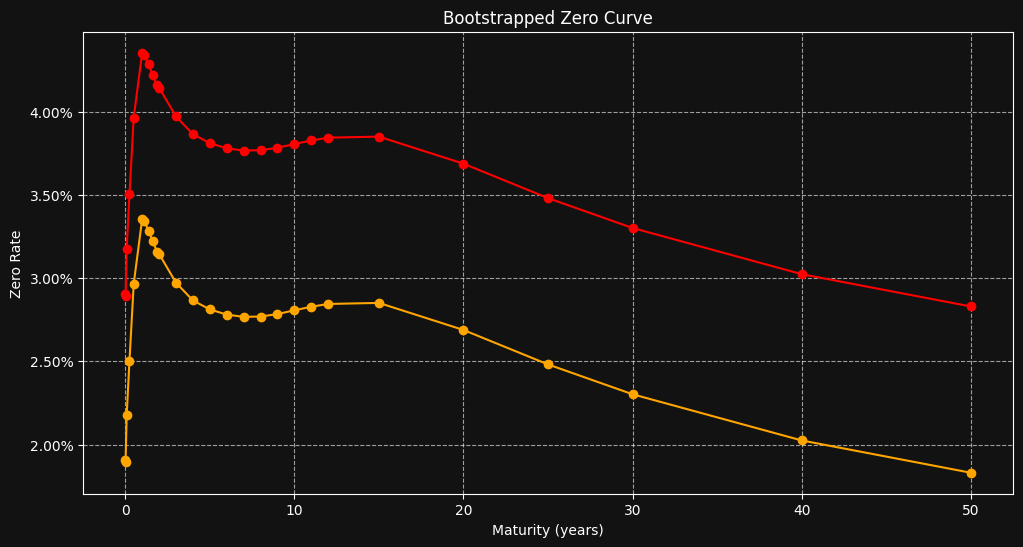

In [9]:
plt.figure(figsize=(12,6))
plt.plot(times, zero_rates, marker="o", color="orange")
plt.plot(times, Shocked_zrates, marker="o", color="red")
plt.title("Bootstrapped Zero Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero Rate")
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=2))
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


### Positive Convexity when expecting higher volatility

If we expect higher volatility, owning positive convexity ie long bonds, means we make more P&L when interest rates decline by a certain amount (50bps) than when they rise by the same amount (50bps) 

In [10]:
M1 = 10
C1 = 0.04
N1 = 1e8
F1 = 2

### Bond Price
Price = bond_pricer(N1, M1, C1, F1, dfs)
print(f"Initial Bond Price is : €{Price:.2f}\n")

### Falling Rates scenario

Shock = -0.0050 # 100 basis point

Shocked_zrates , shocked_DFs = parallel_shock_RF(zero_rates, times , Shock)
Shocked_Price = bond_pricer(N1,M1,C1,F1, shocked_DFs)

print(f"50bp fall in interest rate effect is : €{Shocked_Price:.2f}")

fall_PL = Shocked_Price - Price
print(f"PL =  €{fall_PL:.2f}\n")


### Falling Rates scenario

Shock = 0.0050 # 100 basis point

Shocked_zrates , shocked_DFs = parallel_shock_RF(zero_rates, times , Shock)
Shocked_Price = bond_pricer(N1,M1,C1,F1, shocked_DFs)

print(f"50bp rise in interest rate effect is : €{Shocked_Price:.2f}")

rise_PL = Shocked_Price - Price
print(f"PL =  €{rise_PL:.2f}\n")

difference = fall_PL + rise_PL
print(f"Net Effect =  €{difference:.2f}")
print(f"Net % return =  %{100*difference/Price:.3f}")


Initial Bond Price is : €114306108.07

50bp fall in interest rate effect is : €118502994.71
PL =  €4196886.64

50bp rise in interest rate effect is : €110275132.33
PL =  €-4030975.73

Net Effect =  €165910.91
Net % return =  %0.145


## Carry & Rolldown

When yield curve is steep, Long bond are very attractive, because of carry and roll down.

- **Carry** is simply Periodic income from the bond position, in this case the coupons.

When the yield curve is steep, the financing or opportunity cost (Libor + spread, repo, T-Bills) is lower than the yields of longer bonds, and you can earn excess return by "carrying" the long bonds, this return can be further enhanced by using financial leverage or convex instruments.

In practice when we think about carry,  we look at it as a breakeven measure in yield terms. Dividing by the duration of the bond position, we get how much yield can go up (or down in case of short position) before we lose money on a financed bond position over our holding period.



In [11]:
# Calculate the 5Y5Y forward rate (Starts at Year 1, ends at Year 5)
forward_5y5y = forward_rate_calculator(dfs, t_start=5.0, t_end=10.0)
print(f"1Y4Y Forward Rate: {forward_5y5y:.4%}")

1Y4Y Forward Rate: 2.8017%
